## **Product Category Clustering**

- **Objective:** Simplify the dataset by clustering product categories into 4-6 meta-categories.
- **Task:** Create a model to group all reviews into 4-6 broader categories. Example suggestions:
    - Ebook readers
    - Batteries
    - Accessories (keyboards, laptop stands, etc.)
    - Non-electronics (Nespresso pods, pet carriers, etc.)

Note: Analyze the dataset in depth to determine the most appropriate categories.

In [1]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset, logging
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score


## Section 1: Load and Preprocess the Dataset

In [3]:
# Suppress HF datasets logging
logging.set_verbosity_error()


In [4]:
# 2. LOAD ELECTRONICS METADATA
# Change "raw_meta_Electronics" to another config if you want a different category.
meta_ds = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_Electronics",
    split="full",
    trust_remote_code=True
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/30.3k [00:00<?, ?B/s]

Amazon-Reviews-2023.py:   0%|          | 0.00/39.6k [00:00<?, ?B/s]

meta_Electronics.jsonl:   0%|          | 0.00/5.25G [00:00<?, ?B/s]

Generating full split:   0%|          | 0/1610012 [00:00<?, ? examples/s]

In [5]:
# Convert to Pandas for easy manipulation
meta_df = meta_ds.to_pandas()

# Keep only ASIN and title for clustering
products = meta_df[["parent_asin", "title"]].dropna().reset_index(drop=True)
print(f"Loaded {len(products)} products")

Loaded 1610012 products


## **Section 2: Explore the dateset**

In [6]:
# 1. Inspect DataFrame Structure

print("Columns in meta_df:", meta_df.columns.tolist())
print("\nFirst 5 rows:")
display(meta_df.head())

Columns in meta_df: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']

First 5 rows:


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Electronics,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6,[],[Teleporter V3 The “Teleporter V3” kit sets a ...,None,"{'hi_res': [None], 'large': ['https://m.media-...","{'title': [], 'url': [], 'user_id': []}",Fat Shark,"[Electronics, Television & Video, Video Glasses]","{""Date First Available"": ""August 2, 2014"", ""Ma...",B00MCW7G9M,None,None,None
1,All Electronics,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1,"[UPC: 662774021904, Weight: 0.600 lbs]",[HDMI In - HDMI Out],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",SIIG,"[Electronics, Television & Video, Accessories,...","{""Product Dimensions"": ""0.83 x 4.17 x 2.05 inc...",B00YT6XQSE,None,None,None
2,Computers,Digi-Tatoo Decal Skin Compatible With MacBook ...,4.5,246,[WARNING: Please IDENTIFY MODEL NUMBER on the ...,[],19.99,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': ['AL 2Sides Video', 'MacBook Protect...",Digi-Tatoo,"[Electronics, Computers & Accessories, Laptop ...","{""Brand"": ""Digi-Tatoo"", ""Color"": ""Fresh Marble...",B07SM135LS,None,None,None
3,AMAZON FASHION,NotoCity Compatible with Vivoactive 4 band 22m...,4.5,233,[☛NotoCity 22mm band is designed for Vivoactiv...,[],9.99,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",NotoCity,"[Electronics, Wearable Technology, Clips, Arm ...","{""Date First Available"": ""May 29, 2020"", ""Manu...",B089CNGZCW,None,None,None
4,Cell Phones & Accessories,Motorola Droid X Essentials Combo Pack,3.8,64,"[New Droid X Essentials Combo Pack, Exclusive ...",[all Genuine High Quality Motorola Made Access...,14.99,"{'hi_res': [None, None, None, None, None], 'la...","{'title': [], 'url': [], 'user_id': []}",Verizon,"[Electronics, Computers & Accessories, Compute...","{""Product Dimensions"": ""11.6 x 6.9 x 3.1 inche...",B004E2Z88O,None,None,None


In [7]:
# 2. Unique Main Categories
print("Unique main_category values:")
print(meta_df["main_category"].unique())

Unique main_category values:
['All Electronics' 'Computers' 'AMAZON FASHION'
 'Cell Phones & Accessories' 'Sports & Outdoors' 'Industrial & Scientific'
 None 'Portable Audio & Accessories' 'Camera & Photo' 'Amazon Home'
 'Home Audio & Theater' 'Office Products' 'GPS & Navigation'
 'Musical Instruments' 'Car Electronics' 'Tools & Home Improvement'
 'Toys & Games' 'Amazon Devices' 'Pet Supplies' 'Automotive'
 'Apple Products' 'All Beauty' 'Books' 'Baby' 'Health & Personal Care'
 'Arts, Crafts & Sewing' 'Video Games' 'Appliances' 'Grocery'
 'Premium Beauty' 'Amazon Fire TV' 'Audible Audiobooks' 'Software'
 'Movies & TV' 'Buy a Kindle' 'Magazine Subscriptions' 'Gift Cards'
 'Handmade' 'Fire Phone' 'Collectible Coins' 'Digital Music'
 'Unique Finds' 'Collectibles & Fine Art']


In [8]:
# 3. Nested 'categories' Field
# 'categories' is a list of lists; explode to get individual category paths
exploded = meta_df.explode("categories")["categories"].dropna()

# If each element is itself a list of strings, do a second explode:
exploded = exploded.explode()

print("\nTop 20 most frequent sub‑categories:")
print(exploded.value_counts().head(20))


Top 20 most frequent sub‑categories:
categories
Electronics                           1479731
Computers & Accessories                647666
Camera & Photo                         252668
Accessories                            199555
Computer Accessories & Peripherals     166204
Bags, Cases & Sleeves                  145657
Laptop Accessories                     131630
Tablet Accessories                     126147
Cases                                  122707
Television & Video                     113956
Headphones, Earbuds & Accessories      101853
Computer Components                     97354
Car & Vehicle Electronics               70599
Internal Components                     69171
Portable Audio & Video                  62449
Home Audio                              62214
Cables & Accessories                    57793
Cables & Interconnects                  57684
Computers & Tablets                     57232
Headphones & Earbuds                    56048
Name: count, dtype: int64


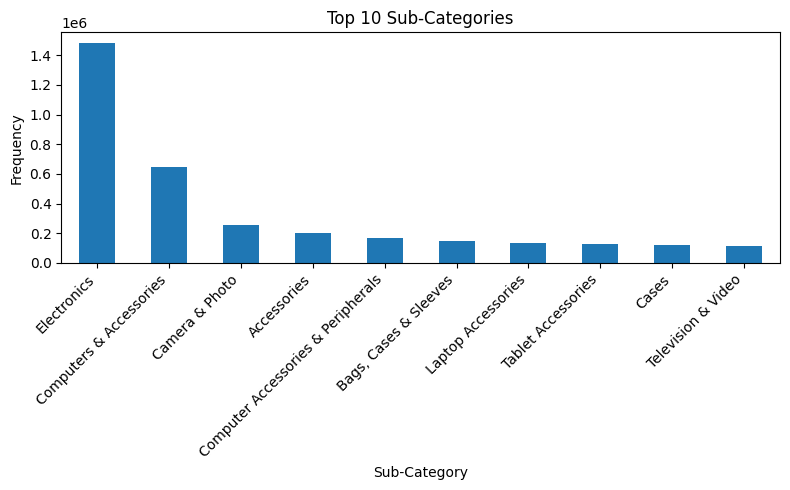

In [9]:
# 4. Quick Visualization of Top Sub‑Categories
import matplotlib.pyplot as plt

top_cats = exploded.value_counts().head(10)
plt.figure(figsize=(8,5))
top_cats.plot(kind="bar")
plt.xlabel("Sub‑Category")
plt.ylabel("Frequency")
plt.title("Top 10 Sub‑Categories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Section 3: Preprocessing the dataset

In [10]:
# VECTORIZE PRODUCT TITLES WITH TF‑IDF
vectorizer = TfidfVectorizer(
    max_features=2000,   # limit vocabulary for speed
    stop_words="english",
    ngram_range=(1,2)
)
X = vectorizer.fit_transform(products["title"])


## Section 4: Clustring using K- mean

- Compute the average silhouette score for different values of 𝑘 [2,3,4,5,6]
- Plot these scores against 𝑘
- Select the 𝑘 that maximizes the silhouette score

This procedure balances cohesion (points close together within a cluster) and separation (clusters well apart). The 𝑘 with the highest average silhouette typically yields the most natural grouping of the data under K‑Means.


**Sweep over k to find the optimal number of clusters.**

k=2: WCSS=1566075.95
k=3: WCSS=1555722.60
k=4: WCSS=1547919.55
k=5: WCSS=1540667.60
k=6: WCSS=1532880.96


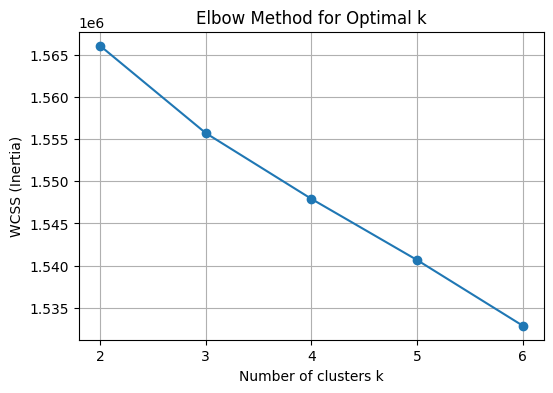

In [12]:
wcss = []
ks = list(range(2, 7))  # try k from 2 to 10

for k in ks:
    # Initialize KMeans with k clusters
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    # inertia_ is the within‑cluster sum of squares (WCSS)
    wcss.append(km.inertia_)

# Print WCSS values for each k
for k, val in zip(ks, wcss):
    print(f"k={k}: WCSS={val:.2f}")

# Plot the Elbow curve to visualize the optimal k
plt.figure(figsize=(6, 4))
plt.plot(ks, wcss, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.xticks(ks)
plt.grid(True)
plt.show()

**Insights from the Elbow Curve (WCSS vs. k)**

- The largest drop in WCSS occurs between k=2 and k=3
This indicates that moving from 2 to 3 clusters significantly improves cluster compactness.

- From k=3 to k=6, the WCSS decreases at a steady but smaller rate
Each additional cluster reduces WCSS by roughly the same amount (~8,000), showing diminishing returns.

- k=3 appears to be the actual “elbow point”
This is where the curve starts to flatten, suggesting a good trade-off between simplicity and effectiveness.




In [21]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
products["cluster"] = km.fit_predict(X)

In [19]:
# INSPECT CLUSTERS TO ASSIGN NAMES

# Helper to show top terms per cluster
def print_top_terms_per_cluster(model, vectorizer, n_terms=10):
    centroids = model.cluster_centers_
    terms = vectorizer.get_feature_names_out()
    for i, centroid in enumerate(centroids):
        top_idxs = centroid.argsort()[::-1][:n_terms]
        top_terms = [terms[idx] for idx in top_idxs]
        print(f"Cluster {i} top terms: {', '.join(top_terms)}")

print_top_terms_per_cluster(km, vectorizer)

Cluster 0 top terms: case, ipad, cover, pro, inch, protective, leather, tablet, stand, air
Cluster 1 top terms: black, camera, laptop, replacement, battery, inch, compatible, wireless, digital, bluetooth
Cluster 2 top terms: cable, usb, adapter, power, cord, charger, ac, male, supply, power supply


In [ ]:

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=products["cluster"], cmap="Set2", s=30)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Product Title Clusters (PCA Projection)")
plt.colorbar(label="Cluster")
plt.show()


In [23]:
# Show 5 sample titles from each cluster
for i in range(3):
    print(f"\nCluster {i} sample titles:")
    display(products[products["cluster"] == i]["title"].sample(5, random_state=42))



Cluster 0 sample titles:


,title
752532,"KABCON Tablet Floor Stand,Tablet Holder Mount ..."
209333,iPad Rotating Case for iPad 4 3 2 (Old Model) ...
508882,iiteeology Compatible with Apple AirPod Case S...
1160792,For LG Octane VN530 Rubberized HARD Protector ...
1476365,Gnome Laptop Case



Cluster 1 sample titles:


,title
1460626,ONUPGO 3.28 ft x 9.8 ft Rose Gold Foil Curtain...
1020607,Sokani X60 Version 2 Updated LED Video Light 8...
1189010,Raspberry Pi Compute Module 4 with CM4 heatsin...
1194574,Bosvision Low Profile Micro SD Adapter for Ras...
1047651,"Aiphone AH108 10W HornStyle Outdoor Speaker, 8..."



Cluster 2 sample titles:


,title
986625,33FT Extra Long Male to Male Universal Aux Aud...
1021011,TypeMatrix 2030 USB - Unlabeled Keyboard
771,"Surge Protector Power Strip, TESSAN 8 Outlets ..."
909471,DuaFire 50 Miles Range Digital Indoor HDTV Ant...
1094562,"USB Type C Cable Fast Charging, ANUEVE USB C t..."


In [24]:
# ASSIGN HUMAN-READABLE META-CATEGORY NAMES
cluster_to_meta = {
    0: "Tablet Accessories",
    1: "Tech Hardware & Gadgets",
    2: "Power & Cables"
}

products["meta_category"] = products["cluster"].map(cluster_to_meta)

# Quick check
print("\nMeta‐category counts:")
print(products["meta_category"].value_counts())



Meta‐category counts:
meta_category
Tech Hardware & Gadgets    1145368
Power & Cables              244918
Tablet Accessories          219726
Name: count, dtype: int64


## Section 5: VISUALIZE META‐CATEGORY DISTRIBUTION

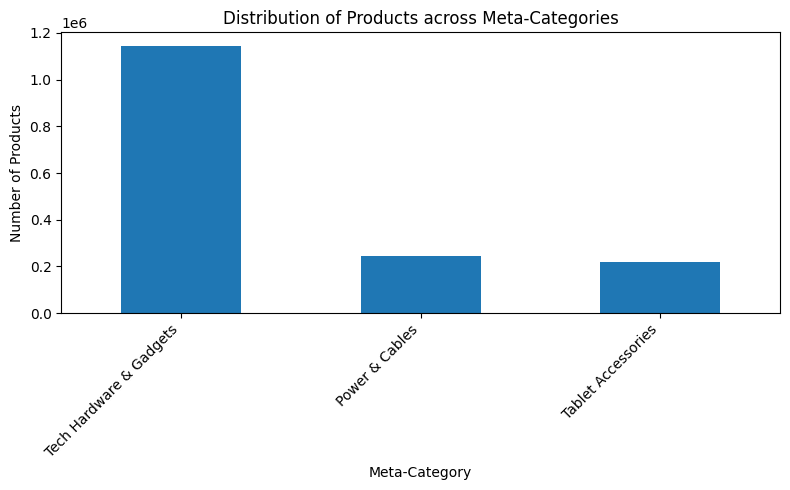

In [25]:
plt.figure(figsize=(8,5))
products["meta_category"].value_counts().plot(kind="bar")
plt.xlabel("Meta‐Category")
plt.ylabel("Number of Products")
plt.title("Distribution of Products across Meta‐Categories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## **SAVE THE MODEL**

In [26]:
import joblib

# 1. Save the KMeans model
joblib.dump(km, "kmeans_model.joblib")

# 2. Save the TF‑IDF vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")

# 3. Save the cluster‑to‑meta mapping
joblib.dump(cluster_to_meta, "cluster_to_meta.joblib")

print("Clustering model, vectorizer, and mapping have been saved.")


Clustering model, vectorizer, and mapping have been saved.
